# Testing a Uniform Pseudorandom-Number Generator

This notebook performs a first statistical check of Python's pseudorandom-number generator. We generate values in the interval $[0,1)$ and ask whether equal-width intervals receive approximately equal numbers of samples.

A flat histogram is necessary for a uniform distribution, but it is not sufficient evidence that a generator is random: correlations or repeating patterns can remain hidden. The goal here is to learn how expected statistical fluctuations scale with sample size.

## What should the histogram look like?

For $N$ independent samples divided among $M$ equal bins, each bin should contain about $N/M$ entries. Counting fluctuations are approximately Poisson, so the fractional one-standard-deviation fluctuation is

$$\frac{\sigma_n}{\langle n\rangle} \approx \frac{1}{\sqrt{N/M}}.$$

The dashed lines below mark three times this value. They are a useful visual guide, not a pass/fail test: with many bins, an occasional bin outside the lines is not surprising.

## Reproducibility and runtime

The seed fixes the pseudorandom sequence, allowing everyone to reproduce the same plot. Increase `npoints` to reduce the expected fractional fluctuations as $1/\sqrt{N}$; decrease it if memory or runtime is limited.

Three-sigma Error = 0.030000


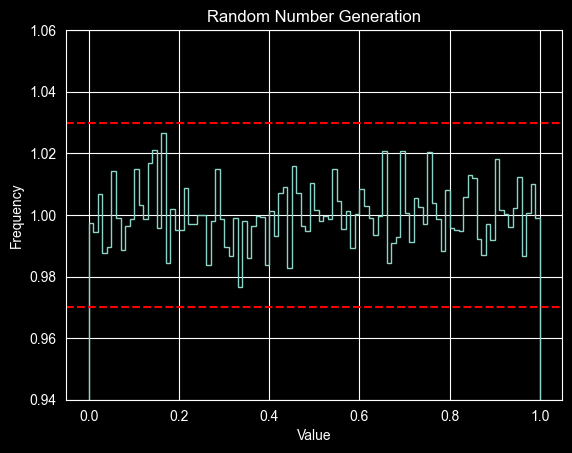

In [1]:
import matplotlib.pyplot as plt
import random
import math

# Set the seed for random number generation
random.seed(1)

# Define the number of points, seed, and number of bins
npoints = 1000000
nbins = 100

# Create a figure and axes
fig, ax = plt.subplots()

# Generate random numbers using the Python random module and fill the histogram
data = [random.random() for _ in range(npoints)]
hist, bins, _ = ax.hist(data, bins=nbins, range=(0.0, 1.0), histtype='step', density=True)

# Calculate the three-sigma error
error = 3.0 / math.sqrt(npoints / nbins)
print("Three-sigma Error = %f" % error)

# Add horizontal lines for error
ax.axhline(1 + error, color='r', linestyle='--')
ax.axhline(1 - error, color='r', linestyle='--')

# Set the y-axis range
ax.set_ylim(1 - 2.0 * error, 1.0 + 2.0 * error)

# Set labels
ax.set_title('Random Number Generation')
ax.set_xlabel('Value')
ax.set_ylabel('Frequency')

# Show the plot
plt.show()


## Interpretation

The histogram should fluctuate around density 1 with no systematic slope or curvature. Rerunning with a different seed changes the individual bin heights but not their expected scale. Try reducing `npoints` by factors of 10 and check that the guide-band width grows by approximately $\sqrt{10}$.